# Notebook 01.5 — Análise Exploratória dos Dados Socioeconômicos (renda e população)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Autor:** Felipe Ramos Dantas  
**Orientador:** Prof. Dr. Antonio Joaquim da Silva  
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs  
**Última atualização:** 2026-06-12

---

## Objetivo

Caracterizar, estatística e cartograficamente, as duas variáveis socioeconômicas que sustentam a pesquisa de acessibilidade: a **população residente** por setor censitário (a demanda $P_i$ do método AE2SFCA) e a **renda do responsável pelo domicílio** (variável de teste da hipótese territorial H2). A análise exploratória (AED) diagnostica a posição, a variabilidade e a forma das distribuições, identifica os valores atípicos (hot-spots de riqueza) e fundamenta as escolhas metodológicas adotadas adiante (uso da mediana, isolamento de outliers em classes próprias, tratamento do MAUP e do sigilo estatístico).

> Os dados socioeconômicos são adquiridos no **NB 01.1 (Apêndice A)**; este notebook apenas os explora (não integra os apêndices).

## Entrada

| Arquivo | Origem |
|---|---|
| `teresina_setoresCensitarios_DadosCompletos.parquet` | NB 01.1 |
| `teresina_zonaUrbana_utm.parquet` | NB 01.1 |

## Saída

| Arquivo | Descrição |
|---|---|
| `outputs/tabelas/nb015/nb051_aed_socioeconomica_resumo.csv` | Medidas de posição, variabilidade e forma |
| `outputs/figuras/nb015/nb051_aed_distribuicao_renda_pop.png` | Histogramas e box plots (renda e população) |
| `outputs/figuras/nb015/nb051_mapa_renda_mediana.png` | Mapa coroplético da renda mediana (faixas de SM) |
| `outputs/figuras/nb015/nb051_mapa_populacao.png` | Mapa coroplético da população (quintis) |

## Pré-requisitos

- NB 01.1 executado (gera o GeoDataFrame mestre com os dados do Censo 2022).

---

## 1. Configuração e importações

Bibliotecas (incl. `scipy.stats` para assimetria/curtose), caminhos, CRS e estilo cartográfico centralizados; criação das subpastas de saída (`nb015`).

In [1]:
# -- 1. IMPORTACOES E CONFIGURACAO GLOBAL ------------------------------------
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis


# Caminhos, CRS e estilo cartografico centralizados (ver src/mapeprof/)
from mapeprof.config import (EXT_PMT, EXT_CNES, EXT_IBGE, INT_MALHA, INT_UBS,
                             FIGURAS, TABELAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import (
    aplicar_estilo, barra_escala, seta_norte, 
    moldura_mapa, formatar_eixos_mapa, ajustar_zoom_camada
)
aplicar_estilo()                       # estilo padrao das figuras da dissertacao

TABELA_NB = TABELAS / "nb015"      # cada notebook grava figuras na própria subpasta
TABELA_NB.mkdir(parents=True, exist_ok=True)

FIGURAS_NB = FIGURAS / "nb015"      # cada notebook grava figuras na própria subpasta
FIGURAS_NB.mkdir(parents=True, exist_ok=True)

print("Dependencias e diretorios prontos.")

Dependencias e diretorios prontos.


## 2. Carga e preparação dos dados

Carregamos o GeoDataFrame mestre produzido no NB 01.1 e renomeamos as três variáveis de interesse para nomes intuitivos. O `merge` do NB 01.1 deixa como `NaN` os setores especiais (condomínios de alto padrão e similares) cujos dados o IBGE omitiu por sigilo estatístico; eles são contabilizados aqui e, por não possuírem valor observado, ficam de fora das estatísticas (o que torna as análises conservadoras).

In [2]:
# -- 2. CARGA E RENOMEACAO PARA NOMES INTUITIVOS -----------------------------
# populacao     = demanda P_i do AE2SFCA            (V01006, Censo 2022 - demografia)
# renda_mediana = indicador-base da H2, resistente  (V06006, renda do responsavel)
# renda_media   = comparacao / robustez             (V06004, renda do responsavel)
setores = gpd.read_parquet(
    INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet"
).to_crs(CRS_METRICO)

# Guarda contra o artefato legado 'X'->0: aqui nao existe setor com populacao ou
# renda zero "de verdade". Valores nao-positivos sinalizam dado omitido pelo IBGE
# por sigilo (marcador X) que versoes antigas do NB 01.1 convertiam em zero.
# Tratamos como ausente (NaN) para nao contaminar a AED com falsos zeros.
suprimidos = (setores["populacao"].fillna(0) <= 0) | (setores["renda_mediana"].fillna(0) <= 0)
setores.loc[suprimidos, ["populacao", "renda_mediana", "renda_media"]] = np.nan

n_total    = len(setores)
n_validos  = int(setores["renda_mediana"].notna().sum())
n_ausentes = int(setores["renda_mediana"].isna().sum())
print(f"setores urbanos: {n_total} | com dado valido: {n_validos} | sem dado (sigilo): {n_ausentes}")

setores urbanos: 1375 | com dado valido: 1340 | sem dado (sigilo): 35


## 3. Estatística descritiva (posição, variabilidade e forma)

Para cada variável calculamos:

- **Posição:** média, mediana e quartis ($Q_1$, $Q_3$).
- **Variabilidade:** desvio-padrão, coeficiente de variação (CV) e distância interquartil (IQR $= Q_3 - Q_1$).
- **Forma:** assimetria (skewness) e curtose.
- **Outliers:** limite superior das cercas de Tukey, $LS = Q_3 + 1{,}5 \times IQR$, e a contagem de setores acima dele.

A mediana e o IQR são medidas **resistentes** (não se deixam distorcer pelas caudas), por isso são as métricas de referência para a renda, fortemente assimétrica.

In [3]:
# -- 3. TABELA DE MEDIDAS DESCRITIVAS ----------------------------------------
VARS = {
    "renda_mediana": "Renda mediana (R$)",
    "renda_media":   "Renda media (R$)",
    "populacao":     "Populacao (hab.)",
}

def resumo(s):
    # Medidas de posicao, variabilidade e forma de uma variavel (ignora NaN).
    s = s.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    ls = q3 + 1.5 * iqr
    return {
        "n":                                int(s.size),
        "Media":                            s.mean(),
        "Mediana":                          s.median(),
        "Minimo":                           s.min(),
        "1o quartil (Q1)":                  q1,
        "3o quartil (Q3)":                  q3,
        "Maximo":                           s.max(),
        "Desvio-padrao":                    s.std(),
        "Coef. de variacao (%)":            s.std() / s.mean() * 100,
        "IQR (Q3 - Q1)":                    iqr,
        "Lim. sup. outlier (Q3+1,5.IQR)":   ls,
        "No de outliers superiores":        int((s > ls).sum()),
        "Assimetria":                       skew(s),
        "Curtose":                          kurtosis(s),
    }

tabela = pd.DataFrame({rotulo: resumo(setores[v]) for v, rotulo in VARS.items()}).round(2)
caminho_tabela = TABELA_NB / "aed_socioeconomica_resumo.csv"
tabela.to_csv(caminho_tabela, sep=";", encoding="utf-8-sig")
print("Tabela salva em:", caminho_tabela)
tabela

Tabela salva em: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\outputs\tabelas\nb015\aed_socioeconomica_resumo.csv


,Renda mediana (R$),Renda media (R$),Populacao (hab.)
n,1340.00,1340.00,1340.00
Media,2151.87,2959.52,602.73
Mediana,1212.00,1930.94,591.00
Minimo,400.00,802.69,14.00
1o quartil (Q1),1212.00,1401.06,416.00
3o quartil (Q3),2000.00,3123.60,786.25
Maximo,19250.00,19864.29,1495.00
Desvio-padrao,2157.08,2801.34,265.04
Coef. de variacao (%),100.24,94.66,43.97
IQR (Q3 - Q1),788.00,1722.54,370.25


## 4. Forma das distribuições (assimetria e outliers)

O histograma e o box plot tornam visível o que a tabela resume em números: a renda é fortemente assimétrica à direita (poucos setores de altíssima renda alongam a cauda superior), enquanto a população é aproximadamente simétrica em torno de cerca de 600 habitantes por setor, refletindo o critério do IBGE de desenhar setores demograficamente homogêneos.

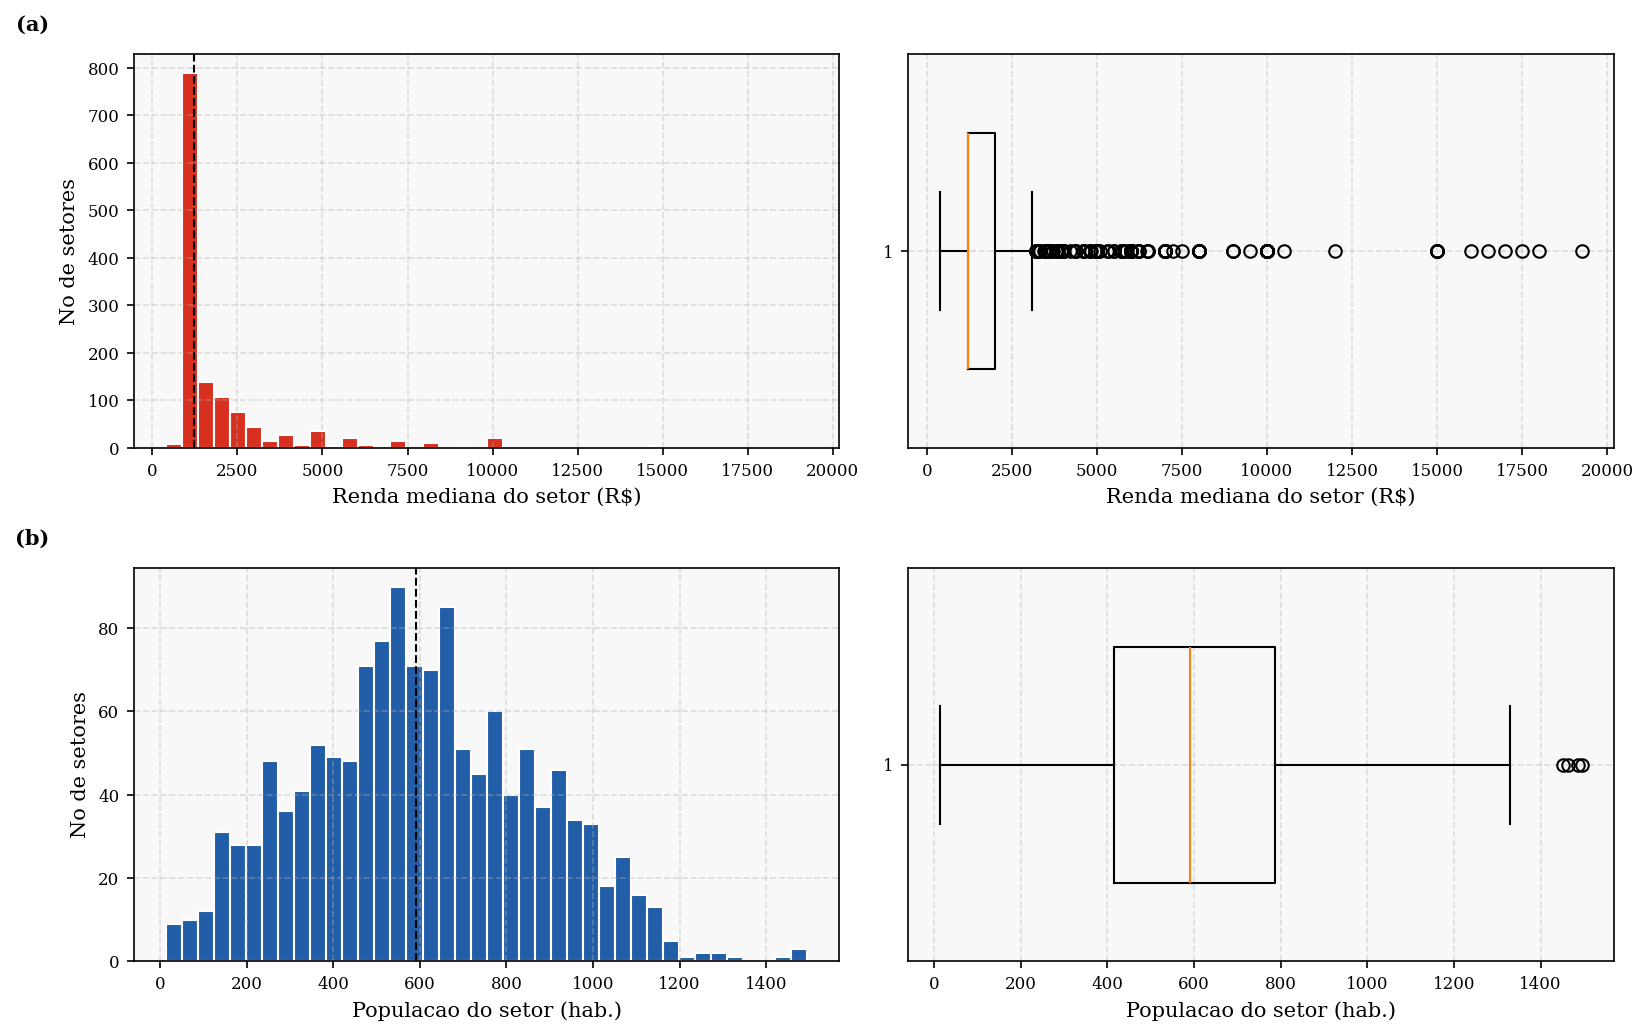

In [4]:
# -- 4. HISTOGRAMAS E BOX PLOTS ----------------------------------------------
val = setores.dropna(subset=["renda_mediana", "populacao"])

fig, axs = plt.subplots(2, 2, figsize=(11, 7))

# ─── LINHA SUPERIOR: RENDA ──────────────────────────────────────────────────
# Renda mediana: histograma + linha da mediana
axs[0, 0].hist(val["renda_mediana"], bins=40, color="#D7301F", edgecolor="white")
axs[0, 0].axvline(val["renda_mediana"].median(), color="black", ls="--", lw=1)
axs[0, 0].set_xlabel("Renda mediana do setor (R$)"); axs[0, 0].set_ylabel("No de setores")
axs[0, 1].boxplot(val["renda_mediana"], vert=False, widths=0.6)
axs[0, 1].set_xlabel("Renda mediana do setor (R$)")

# Inserindo o indicador (a)
axs[0, 0].text(-0.12, 1.05, "(a)", transform=axs[0, 0].transAxes, 
               fontsize=10, fontweight="bold", va="bottom", ha="right")


# ─── LINHA INFERIOR: POPULAÇÃO ──────────────────────────────────────────────
# Populacao: histograma + linha da mediana
axs[1, 0].hist(val["populacao"], bins=40, color="#225EA8", edgecolor="white")
axs[1, 0].axvline(val["populacao"].median(), color="black", ls="--", lw=1)
axs[1, 0].set_xlabel("Populacao do setor (hab.)"); axs[1, 0].set_ylabel("No de setores")
axs[1, 1].boxplot(val["populacao"], vert=False, widths=0.6)
axs[1, 1].set_xlabel("Populacao do setor (hab.)")

# Inserindo o indicador (b)
axs[1, 0].text(-0.12, 1.05, "(b)", transform=axs[1, 0].transAxes, 
               fontsize=10, fontweight="bold", va="bottom", ha="right")

# ────────────────────────────────────────────────────────────────────────────
fig.tight_layout()
fig.savefig(FIGURAS_NB / "nb051_aed_distribuicao_renda_pop.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Mapas graduados das variáveis críticas

Os mapas coropléticos espacializam as duas variáveis sobre a malha de setores da zona urbana.

- **Renda mediana:** as classes seguem **múltiplos do salário mínimo de 2022 (R$ 1.212)**. Essa escolha é interpretável (cada classe é uma faixa de poder de compra) e isola os hot-spots de riqueza (acima de 5 salários mínimos) numa classe própria, conforme recomendado para variáveis fortemente assimétricas. Os setores em cinza são os omitidos por sigilo.
- **População:** classificada em quintis (cinco classes de igual número de setores), adequada por ser uma variável aproximadamente simétrica.

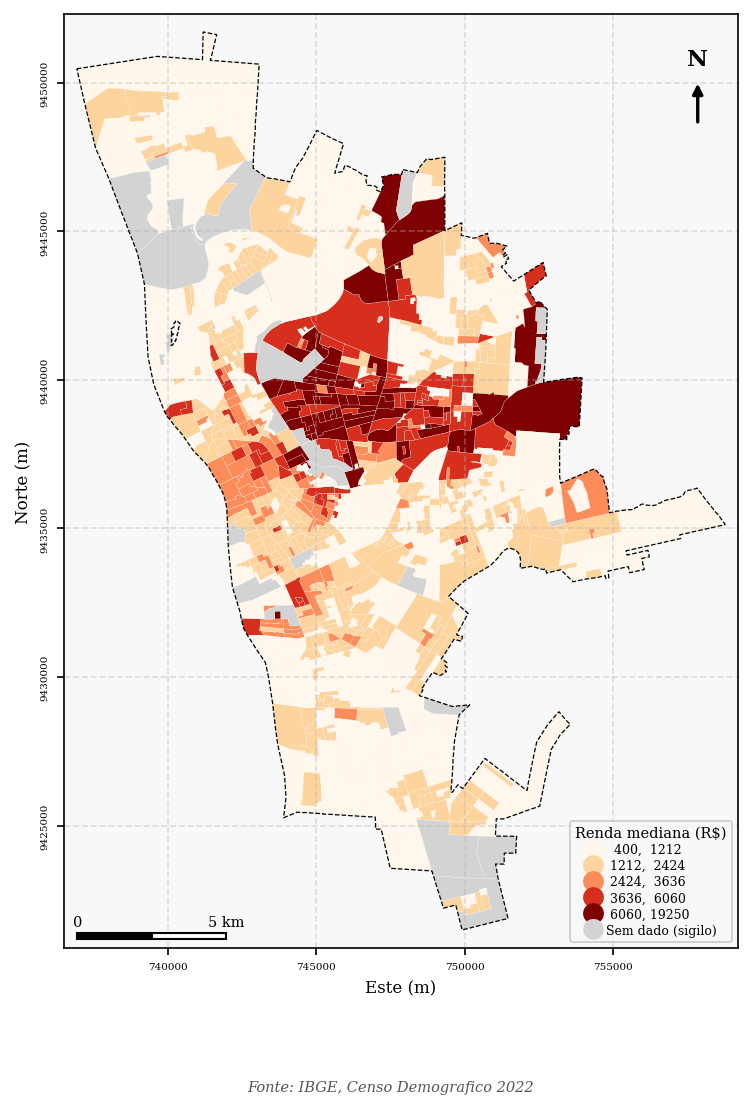

In [ ]:
# -- 5. MAPA: RENDA MEDIANA (classes em multiplos do salario minimo) ---------
SM_2022 = 1212  # salario minimo vigente no Censo 2022
bins = [1 * SM_2022, 2 * SM_2022, 3 * SM_2022, 5 * SM_2022,
        float(setores["renda_mediana"].max())]

zona = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)

# Mantemos a definição da Folha A5 Retrato na criação da figura
fig, ax = plt.subplots(figsize=(5.8, 8.3))
setores.plot(
    ax=ax, column="renda_mediana", scheme="UserDefined",
    classification_kwds={"bins": bins}, cmap="OrRd", legend=True,
    legend_kwds={"title": "Renda mediana (R$)", "loc": "lower right", "fmt": "{:.0f}"},
    edgecolor="white", linewidth=0.1,
    missing_kwds={"color": "lightgrey", "label": "Sem dado (sigilo)"},
)
zona.boundary.plot(ax=ax, color="black", ls="--", lw=0.6)

formatar_eixos_mapa(ax)                  # Aplica a rotação, fontes e remove o 1e6
ajustar_zoom_camada(ax, setores)         # Elimina o espaço em branco superior/inferior
moldura_mapa(ax, "", "IBGE, Censo Demografico 2022")
barra_escala(ax)
seta_norte(ax)

fig.savefig(FIGURAS_NB / "nb051_mapa_renda_mediana.png", dpi=300, bbox_inches="tight")
plt.show()

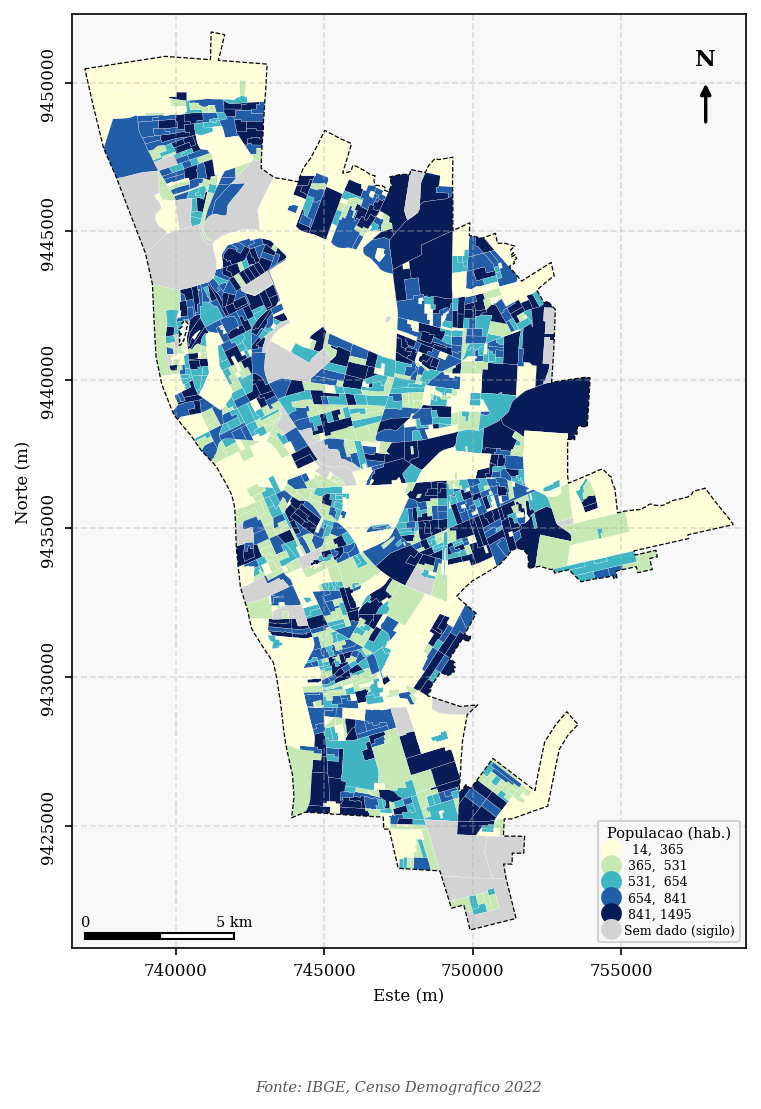

In [6]:
# -- 6. MAPA: POPULACAO (quintis) --------------------------------------------
fig, ax = plt.subplots(figsize=(5.8, 8.3))
setores.plot(
    ax=ax, column="populacao", scheme="Quantiles", k=5, cmap="YlGnBu", legend=True,
    legend_kwds={
        "title": "Populacao (hab.)", 
        "loc": "lower right", 
        "fmt": "{:.0f}",
    },
    edgecolor="white", linewidth=0.1,
    missing_kwds={"color": "lightgrey", "label": "Sem dado (sigilo)"},
)
zona.boundary.plot(ax=ax, color="black", ls="--", lw=0.6)

ajustar_zoom_camada(ax, setores)         # Elimina o espaço em branco superior/inferior
moldura_mapa(ax, "", "IBGE, Censo Demografico 2022")
formatar_eixos_mapa(ax)            # por último, para ter a palavra final sobre os eixos
barra_escala(ax); seta_norte(ax)

fig.savefig(FIGURAS_NB / "nb051_mapa_populacao.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Próximos passos

A caracterização socioeconômica fundamenta as escolhas metodológicas (uso da renda **mediana**, classes próprias para outliers). A renda mediana por setor é retomada no **NB 06.1** (teste da hipótese territorial H2, acesso × renda).